In [23]:
from langgraph.graph import StateGraph, START, END 
from typing import TypedDict, Literal


In [24]:
class QuadState(TypedDict):

    a: int
    b: int
    c: int

    equation: str
    discriminant: float

    result: str

In [25]:
def show_eq (state: QuadState):
    eq = f'{state['a']}x2{state['b']}x{state['c']}'

    return {'equation': eq}

def calculate_d(state : QuadState):
   d = state['b']**2 - (4*state['a']*state['c'])

   return {'discriminant' : d}

def real_roots(state: QuadState):
    root1= (-state['b']+ state["discriminant"]**0.5)/(2*state['a'])
    root2= (-state['b']- state["discriminant"]**0.5)/(2*state['a'])
    result = f'The roots are {root1} and {root2}'

    return {'result': result}

def repeated_roots(state: QuadState):
    root = (-state['b'])/(2*state['a'])
    result = f'Only Repeating root is {root}'

    return {'result': result}

def no_real_roots(state:QuadState):

    result = f'No real roots'

    return {'result': result}

def check_condition(state: QuadState) -> Literal["real_roots","repeated_roots","no_real_roots"]:
    if state['discriminant'] > 0:
        return "real_roots"
    elif state['discriminant'] == 0:
        return "repeated_roots"
    else :
        return "no_real_roots"

In [26]:
graph = StateGraph(QuadState)

graph.add_node('show_eq', show_eq)
graph.add_node('calculate_d', calculate_d)
graph.add_node('real_roots', real_roots)
graph.add_node('repeated_roots', repeated_roots)
graph.add_node('no_real_roots', no_real_roots)

graph.add_edge(START,'show_eq')
graph.add_edge('show_eq', 'calculate_d')
graph.add_conditional_edges('calculate_d',check_condition)
graph.add_edge('real_roots', END)
graph.add_edge('repeated_roots', END)
graph.add_edge('no_real_roots', END)

workflow= graph.compile()


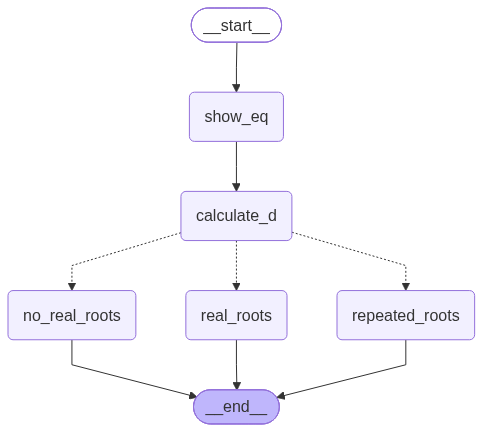

In [27]:
workflow

In [30]:
initial_state = {
    'a': 2,
    'b': 4,
    'c': 4
}

workflow.invoke(initial_state)

{'a': 2,
 'b': 4,
 'c': 4,
 'equation': '2x24x4',
 'discriminant': -16,
 'result': 'No real roots'}